# PARADE UTR Prediction & Design

![PARADE UTR Prediction & Design](https://proto-bio.github.io/proto-assets/images/tool/parade/hero.png)

PARADE (Prediction And RAtional DEsign of mRNA UTRs; [Khoroshkin et al., 2024](https://doi.org/10.1101/2024.12.31.630783)) is a LegNet convolutional model for the untranslated regions of mRNA. This toolkit wraps it as three tools: `parade-activity` (cell-type-specific 5'/3' UTR activity), `parade-stability` (3' UTR mRNA stability as an RNA/gDNA log-ratio), and `parade-gradient` (a differentiable UTR-activity objective and gradient for gradient-based design).

This notebook scores UTRs with each tool, then uses `parade-gradient` in a short Fast SeqProp loop to *design* UTRs whose predicted activity is specific to one cell line over another. PARADE uses anonymized cell-line codes: the 5'UTR panel is `c1, c2, c4, c6, c17` and the 3'UTR panel adds `c13` (`c2` is HepG2). The published checkpoints download automatically on first use from a pinned `autosome-ru/parade` commit into the managed model cache; a GPU speeds things up but everything below also runs on CPU (set `DEVICE = "cpu"`).

In [1]:
from proto_tools.utils.notebook_docs import (
    display_api_reference,
    display_available_tools,
    display_doc_link,
    display_docs_section,
    display_overview,
)

display_doc_link("parade")                    # link to the hosted docs page
display_overview("parade")                    # one-paragraph summary
display_docs_section("parade", "Background")  # scientific background from the toolkit README

# PARADE

PARADE (Prediction And RAtional DEsign of mRNA UTRs) is a LegNet convolutional model for predicting cell-type-specific untranslated-region (UTR) activity and 3' UTR mRNA stability. This toolkit scores 5'/3' UTR sequences across the PARADE cell-line panel and predicts RNA/gDNA stability, using the checkpoints published with the paper.

PARADE ([Khoroshkin et al., 2024](https://doi.org/10.1101/2024.12.31.630783)) is a generative framework for designing UTRs with tailored cell-type-specific activity. Its predictive core adapts the DREAM-challenge LegNet architecture: an EfficientNet-style convolutional network with squeeze-and-excite blocks that reads a one-hot UTR sequence plus a reading-frame positional channel and, for activity, broadcast cell-condition channels.

The activity models are trained per construct type — one for 5' UTRs and one for 3' UTRs — and condition on a panel of anonymized cell-line codes (`c1`, `c2`, `c4`, `c6`, `c17`, and, for 3' UTRs, `c13`), returning a predicted activity mass-center for each. A separate 3' UTR model predicts mRNA stability as an RNA/gDNA log-ratio. The featurization matches the upstream reference pipeline exactly, so predictions reproduce the published values.

## Available tools

In [2]:
display_available_tools("parade")

- **`run_parade_activity()`** — Predict cell-type-specific 5'/3' UTR activity with the PARADE LegNet model
- **`run_parade_gradient()`** — Compute differentiable PARADE UTR-activity losses and gradients for relaxed UTR logits
- **`run_parade_stability()`** — Predict 3' UTR mRNA stability (RNA/gDNA log-ratio) with the PARADE LegNet model

### `run_parade_activity`

Predicts an activity value **per requested cell code** for each UTR. Set `construct_type` to `utr5` or `utr3` (it selects the checkpoint and cell-code panel); leave `cell_types` empty to score the full panel. Upstream trained the 5'UTR model on ~50-nt inserts and the 3'UTR model on ~240-nt inserts, so score near those lengths. Mixed lengths in one call are batched per length group, and RNA input (`U`) is mapped to DNA (`T`).

In [3]:
from proto_tools.tools import ParadeActivityConfig, ParadeActivityInput, run_parade_activity

# The tool runs the model inside its own isolated environment; DEVICE only selects that worker's
# device. Use "cpu" if you don't have a CUDA GPU.
DEVICE = "cuda"

In [4]:
display_api_reference("parade-activity", "input", "run_parade_activity")

# Three 50-nt 5'UTR inserts to score across the full 5'UTR panel.
utrs = [
    "GCACCATGGTGAGCAAGGGCGAGGAGCTGTTCACCGGGGTGGTGCCCATC",  # GC-rich insert
    "AAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA",  # low-complexity control
    "GCGCGCGCGCGCGCGCGCGCGCGCGCGCGCGCGCGCGCGCGCGCGCGCGC",
]
inputs = ParadeActivityInput(sequences=utrs)

**Input** — `ParadeSequenceInput`

| Field | Type | Default | Description |
|-------|------|---------|-------------|
| <code>sequences</code> | <code>list[str]</code> | required | UTR sequence(s) to score; RNA (U) is accepted and mapped to DNA (T). |

In [5]:
display_api_reference("parade-activity", "config", "run_parade_activity")

# cell_types left empty -> the full 5'UTR panel (c1, c2, c4, c6, c17).
config = ParadeActivityConfig(construct_type="utr5", device=DEVICE)

**Config** — `ParadeActivityConfig`

| Field | Type | Default | Description |
|-------|------|---------|-------------|
| <code>verbose</code> | <code>int</code> | <code>0</code> | Verbosity level (0=quiet, 1=info, 2=debug, 3=raw subprocess stderr). True→1, False→0. |
| <code>device</code> | <code>str</code> | <code>'cuda'</code> | Device to run PARADE inference on. |
| <code>timeout</code> | <code>int &#124; None</code> | <code>3600</code> | Maximum execution time in seconds. None waits indefinitely. |
| <code>seed</code> | <code>int &#124; None</code> | <code>None</code> | Random seed for reproducible results. Some cacheable tools gate cache on this field. |
| <code>checkpoint_path</code> | <code>str</code> | <code>''</code> | Optional local PARADE .ckpt path; empty downloads the pinned upstream checkpoint. |
| <code>checkpoint_url</code> | <code>str</code> | <code>''</code> | HTTPS checkpoint override (local only; rejected on device='cloud'); empty uses pinned URL. |
| <code>checkpoint_md5</code> | <code>str</code> | <code>''</code> | MD5 override; empty = pinned checksum for the pinned URL, or no verification for a custom URL. |
| <code>batch_size</code> | <code>int</code> | <code>1</code> | Number of sequences to score simultaneously on GPU. |
| <code>construct_type</code> | <code>Literal['utr5', 'utr3']</code> | <code>'utr5'</code> | UTR model to use: 'utr5' (5' UTR) or 'utr3' (3' UTR). |
| <code>cell_types</code> | <code>list[Literal['c1', 'c2', 'c4', 'c6', 'c17', 'c13']]</code> | <code>[]</code> | PARADE cell codes to return; empty returns the full panel for the construct type. |

In [6]:
activity = run_parade_activity(inputs, config)

Running run_parade_activity [00:00]

In [7]:
display_api_reference("parade-activity", "output", "run_parade_activity")

# `activity.results` is one item per input; `result.scores` is a metrics container keyed by cell code.
cols = activity.cell_types
print("sequence           | " + " | ".join(f"{c:>7}" for c in cols))
for r in activity.results:
    row = dict(r.scores.items())
    print(f"{r.sequence[:16]:<18} | " + " | ".join(f"{row[c]:7.3f}" for c in cols))

**Output** — `ParadeActivityOutput`

| Field | Type | Default | Description |
|-------|------|---------|-------------|
| <code>results</code> | <code>list[ParadeActivityResult]</code> | <code>[]</code> | Per-sequence PARADE activity scoring results |

**`ParadeActivityResult`**

| Field | Type | Default | Description |
|-------|------|---------|-------------|
| <code>sequence</code> | <code>str</code> | required | UTR sequence scored by PARADE |
| <code>sequence_length</code> | <code>int</code> | required | Length of the scored UTR sequence |
| <code>construct_type</code> | <code>Literal['utr5', 'utr3']</code> | required | UTR model that produced these scores |
| <code>scores</code> | <code>ParadeActivityMetrics</code> | required | PARADE activity predictions keyed by cell code |

**Metrics** — `ParadeActivityMetrics` (one set per `results` item)

| Metric | Type | Range | Unit | Description |
|--------|------|-------|------|-------------|
| <code>c1</code> | <code>float</code> |  |  | Predicted PARADE UTR activity for cell code c1. |
| <code>c2</code> | <code>float</code> |  |  | Predicted PARADE UTR activity for cell code c2. |
| <code>c4</code> | <code>float</code> |  |  | Predicted PARADE UTR activity for cell code c4. |
| <code>c6</code> | <code>float</code> |  |  | Predicted PARADE UTR activity for cell code c6. |
| <code>c17</code> | <code>float</code> |  |  | Predicted PARADE UTR activity for cell code c17. |
| <code>c13</code> | <code>float</code> |  |  | Predicted PARADE UTR activity for cell code c13. |

sequence           |      c1 |      c2 |      c4 |      c6 |     c17
GCACCATGGTGAGCAA   |   2.373 |   2.353 |   2.305 |   2.341 |   2.334
AAAAAAAAAAAAAAAA   |   1.820 |   2.199 |   1.949 |   1.777 |   1.860
GCGCGCGCGCGCGCGC   |   2.453 |   2.487 |   2.839 |   2.610 |   3.294


### `run_parade_stability`

Predicts 3' UTR mRNA stability as an RNA/gDNA **log-ratio** — higher is more stable, one value per sequence (there is no cell conditioning). Upstream trained this model on 186-nt sequences, so score near that length.

In [8]:
from proto_tools.tools import ParadeStabilityConfig, ParadeStabilityInput, run_parade_stability

In [9]:
display_api_reference("parade-stability", "input", "run_parade_stability")

# The stability model was trained on 186-nt 3'UTR sequences; score near that length.
stability_inputs = ParadeStabilityInput(sequences=["ACGT" * 46 + "AC", "TGCA" * 46 + "GT"])  # 186 nt

**Input** — `ParadeSequenceInput`

| Field | Type | Default | Description |
|-------|------|---------|-------------|
| <code>sequences</code> | <code>list[str]</code> | required | UTR sequence(s) to score; RNA (U) is accepted and mapped to DNA (T). |

In [10]:
display_api_reference("parade-stability", "config", "run_parade_stability")

stability_config = ParadeStabilityConfig(device=DEVICE)

**Config** — `ParadeCheckpointConfig`

| Field | Type | Default | Description |
|-------|------|---------|-------------|
| <code>verbose</code> | <code>int</code> | <code>0</code> | Verbosity level (0=quiet, 1=info, 2=debug, 3=raw subprocess stderr). True→1, False→0. |
| <code>device</code> | <code>str</code> | <code>'cuda'</code> | Device to run PARADE inference on. |
| <code>timeout</code> | <code>int &#124; None</code> | <code>3600</code> | Maximum execution time in seconds. None waits indefinitely. |
| <code>seed</code> | <code>int &#124; None</code> | <code>None</code> | Random seed for reproducible results. Some cacheable tools gate cache on this field. |
| <code>checkpoint_path</code> | <code>str</code> | <code>''</code> | Optional local PARADE .ckpt path; empty downloads the pinned upstream checkpoint. |
| <code>checkpoint_url</code> | <code>str</code> | <code>''</code> | HTTPS checkpoint override (local only; rejected on device='cloud'); empty uses pinned URL. |
| <code>checkpoint_md5</code> | <code>str</code> | <code>''</code> | MD5 override; empty = pinned checksum for the pinned URL, or no verification for a custom URL. |
| <code>batch_size</code> | <code>int</code> | <code>1</code> | Number of sequences to score simultaneously on GPU. |

In [11]:
stability = run_parade_stability(stability_inputs, stability_config)

Running run_parade_stability [00:00]

In [12]:
display_api_reference("parade-stability", "output", "run_parade_stability")

for r in stability.results:
    print(f"{r.sequence[:16]}...  log_ratio = {r.log_ratio:+.3f}")

**Output** — `ParadeStabilityOutput`

| Field | Type | Default | Description |
|-------|------|---------|-------------|
| <code>results</code> | <code>list[ParadeStabilityResult]</code> | <code>[]</code> | Per-sequence PARADE stability scoring results |

**`ParadeStabilityResult`**

| Field | Type | Default | Description |
|-------|------|---------|-------------|
| <code>sequence</code> | <code>str</code> | required | 3' UTR sequence scored by PARADE |
| <code>sequence_length</code> | <code>int</code> | required | Length of the scored UTR sequence |
| <code>scores</code> | <code>ParadeStabilityMetrics</code> | required | PARADE stability metrics keyed by metric name |

**Metrics** — `ParadeStabilityMetrics` (one set per `results` item)

| Metric | Type | Range | Unit | Description |
|--------|------|-------|------|-------------|
| <code>log_ratio</code> **(primary)** | <code>float</code> |  |  | Predicted PARADE RNA/gDNA log-ratio; higher is more stable. |

ACGTACGTACGTACGT...  log_ratio = -0.691
TGCATGCATGCATGCA...  log_ratio = -0.900


### `run_parade_gradient`

The design primitive. Instead of a discrete sequence it takes **relaxed logits** of shape `(batch, length, 4)` — a soft, differentiable stand-in for a one-hot sequence — and returns the **gradient of a cell-type objective** with respect to those logits. The objective sums `ParadeGradientLossTerm`s; each names a `cell_type` and a `direction` (`max` pushes that cell's activity up, `min` pushes it down), so "maximize `c2`, minimize `c6`" is a cell-type-specificity objective.

In [13]:
import matplotlib.pyplot as plt
import numpy as np

from proto_tools.tools import (
    ParadeGradientConfig,
    ParadeGradientInput,
    ParadeGradientLossTerm,
    run_parade_gradient,
)

# parade-gradient works on relaxed nucleotide logits with columns in A,C,G,T order.
VOCAB = "ACGT"

In [14]:
display_api_reference("parade-gradient", "input", "run_parade_gradient")

# One random candidate: relaxed logits of shape (batch=1, length=50, 4).
rng = np.random.default_rng(0)
gradient_inputs = ParadeGradientInput(logits=rng.normal(0, 1, size=(1, 50, 4)).tolist(), temperature=1.0)

**Input** — `ParadeGradientInput`

| Field | Type | Default | Description |
|-------|------|---------|-------------|
| <code>logits</code> | <code>list[list[list[float]]]</code> | required | Batched relaxed UTR logits with shape (B, L, 4) in A,C,G,T order. |
| <code>temperature</code> | <code>float</code> | <code>1.0</code> | Softmax temperature used to convert logits into relaxed nucleotide probabilities. |

In [15]:
display_api_reference("parade-gradient", "config", "run_parade_gradient")

# Maximize c2 activity, minimize c6 -> a cell-type-specificity objective.
gradient_config = ParadeGradientConfig(
    construct_type="utr5",
    loss_terms=[
        ParadeGradientLossTerm(cell_type="c2", direction="max"),
        ParadeGradientLossTerm(cell_type="c6", direction="min"),
    ],
    device=DEVICE,
)

**Config** — `ParadeGradientConfig`

| Field | Type | Default | Description |
|-------|------|---------|-------------|
| <code>verbose</code> | <code>int</code> | <code>0</code> | Verbosity level (0=quiet, 1=info, 2=debug, 3=raw subprocess stderr). True→1, False→0. |
| <code>device</code> | <code>str</code> | <code>'cuda'</code> | Device to run PARADE inference on. |
| <code>timeout</code> | <code>int &#124; None</code> | <code>3600</code> | Maximum execution time in seconds. None waits indefinitely. |
| <code>seed</code> | <code>int &#124; None</code> | <code>None</code> | Random seed for reproducible results. Some cacheable tools gate cache on this field. |
| <code>construct_type</code> | <code>Literal['utr5', 'utr3']</code> | <code>'utr5'</code> | UTR model to use: 'utr5' (5' UTR) or 'utr3' (3' UTR). |
| <code>loss_terms</code> | <code>list[ParadeGradientLossTerm]</code> | <code>[ParadeGradientLossTerm(cell_type='c2', direction='max', weight=1.0, sigmoid_center=2.0, sigmoid_scale=1.0)]</code> | Per-cell PARADE activity objectives to sum before backpropagation. |
| <code>checkpoint_path</code> | <code>str</code> | <code>''</code> | Optional local PARADE .ckpt path; empty downloads the pinned upstream checkpoint. |
| <code>checkpoint_url</code> | <code>str</code> | <code>''</code> | HTTPS checkpoint override (local only; rejected on device='cloud'); empty uses pinned URL. |
| <code>checkpoint_md5</code> | <code>str</code> | <code>''</code> | MD5 override; empty = pinned checksum for the pinned URL, or no verification for a custom URL. |
| <code>soft</code> | <code>float</code> | <code>1.0</code> | Blend hard argmax one-hot (0) to softmax probabilities (1). |
| <code>hard</code> | <code>float</code> | <code>0.0</code> | Straight-through hard-forward coefficient. |
| <code>compute_gradient</code> | <code>bool</code> | <code>True</code> | Run backward pass and return gradient; set False for forward-only scoring. |

In [16]:
gradient = run_parade_gradient(gradient_inputs, gradient_config)

Running run_parade_gradient [00:00]

In [17]:
display_api_reference("parade-gradient", "output", "run_parade_gradient")

g = np.array(gradient.gradient)   # (1, 50, 4): dLoss/dlogits
raw = gradient.sample_metrics[0]  # per-design raw activities for the objective cells
print("loss           :", round(gradient.loss, 4))
print("gradient shape :", g.shape)
print("raw c2 activity:", round(raw["c2"], 3), "| raw c6 activity:", round(raw["c6"], 3))

**Output** — `ParadeGradientOutput`

| Field | Type | Default | Description |
|-------|------|---------|-------------|
| <code>gradient</code> | <code>list[list[list[float]]] &#124; None</code> | <code>None</code> | Gradient w.r.t. input logits. None when compute_gradient=False. |
| <code>loss</code> | <code>float</code> | required | Sum of per-sample weighted PARADE sigmoid objective values. |
| <code>metrics</code> | <code>dict[str, Any]</code> | <code>{}</code> | Auxiliary metrics reported alongside the scalar objective value. |
| <code>vocab</code> | <code>list[str]</code> | required | Symbols defining the column ordering for both the input logits and the returned gradient. |
| <code>sample_metrics</code> | <code>list[ParadeGradientSampleMetrics]</code> | <code>[]</code> | Per-sample PARADE objective metrics. |

**Metrics** — `ParadeGradientSampleMetrics`

| Metric | Type | Range | Unit | Description |
|--------|------|-------|------|-------------|
| <code>loss</code> **(primary)** | <code>float</code> | <code>&gt;= 0</code> |  | Weighted scalar PARADE objective value for one sample. |
| <code>c1</code> | <code>float</code> |  |  | Raw PARADE UTR activity for cell code c1. |
| <code>c2</code> | <code>float</code> |  |  | Raw PARADE UTR activity for cell code c2. |
| <code>c4</code> | <code>float</code> |  |  | Raw PARADE UTR activity for cell code c4. |
| <code>c6</code> | <code>float</code> |  |  | Raw PARADE UTR activity for cell code c6. |
| <code>c17</code> | <code>float</code> |  |  | Raw PARADE UTR activity for cell code c17. |
| <code>c13</code> | <code>float</code> |  |  | Raw PARADE UTR activity for cell code c13. |

loss           : 1.0876
gradient shape : (1, 50, 4)
raw c2 activity: 2.666 | raw c6 activity: 3.088


## Design cell-type-specific UTRs (Fast SeqProp)

We turn the gradient into a design loop, [Fast SeqProp](https://doi.org/10.1186/s12859-021-04437-5)-style: start from random relaxed logits and repeatedly (1) ask `parade-gradient` for the gradient of the specificity objective, then (2) take an **Adam** step on the logits. Descending the loss raises on-target activity and lowers off-target activity, so specificity `activity(on) - activity(off)` climbs; at the end we `argmax` the logits into a concrete DNA sequence.

In [18]:
def decode(logits):
    """Decode (N, L, 4) relaxed logits to DNA strings by per-position argmax (A,C,G,T order)."""
    return ["".join(VOCAB[i] for i in row.argmax(-1)) for row in logits]


def design_specific_utrs(
    construct_type, on_target, off_target,
    seq_len=50, n_designs=8, steps=50, lr=0.5, seed=0, device=DEVICE, log_every=10,
):
    """Fast SeqProp design of UTRs whose activity is specific to `on_target` over `off_target`.

    Optimizes a batch of `n_designs` relaxed logit tensors in parallel with Adam, driving the
    parade-gradient specificity objective. Returns (history, designs):
      - history: mean (on - off) predicted activity across the batch, per step (the climb);
      - designs: the final decoded DNA sequences.
    """
    # Start near a uniform distribution over nucleotides (small logits -> flat softmax), so the
    # optimizer isn't biased toward any starting sequence.
    rng = np.random.default_rng(seed)
    logits = 0.1 * rng.standard_normal((n_designs, seq_len, 4))

    # Adam optimizer state (first/second moment estimates) and hyperparameters.
    m = np.zeros_like(logits)
    v = np.zeros_like(logits)
    b1, b2, eps = 0.9, 0.999, 1e-8

    # The specificity objective is fixed across steps: push on_target up, off_target down.
    config = ParadeGradientConfig(
        construct_type=construct_type,
        loss_terms=[
            ParadeGradientLossTerm(cell_type=on_target, direction="max"),
            ParadeGradientLossTerm(cell_type=off_target, direction="min"),
        ],
        device=device,
    )

    history = []
    for t in range(1, steps + 1):
        # 1) One differentiable evaluation of the whole batch. temperature=1.0 is a plain softmax
        #    relaxation of the logits into nucleotide probabilities.
        out = run_parade_gradient(ParadeGradientInput(logits=logits.tolist(), temperature=1.0), config)

        # 2) Read the gradient of the loss w.r.t. the logits, same shape as `logits`.
        grad = np.array(out.gradient)  # (n_designs, L, 4)

        # 3) Track the mean specificity for this step. `sample_metrics[i]` carries the raw activity
        #    of each objective cell for design i, so specificity_i = activity(on) - activity(off).
        spec = float(np.mean([sm[on_target] - sm[off_target] for sm in out.sample_metrics]))
        history.append(spec)

        # 4) Adam update. We DESCEND the loss (subtract the step); because loss falls as on-target
        #    activity rises and off-target falls, the specificity we track goes up.
        m = b1 * m + (1 - b1) * grad
        v = b2 * v + (1 - b2) * grad ** 2
        m_hat = m / (1 - b1 ** t)
        v_hat = v / (1 - b2 ** t)
        logits -= lr * m_hat / (np.sqrt(v_hat) + eps)

        if log_every and (t == 1 or t % log_every == 0):
            print(f"  step {t:3d} | mean {on_target}-{off_target} specificity = {spec:+.3f}")

    # Collapse the optimized soft logits to concrete sequences.
    return history, decode(logits)

### Design 5'UTRs specific to `c2` over `c6`

In [19]:
hist_utr5, designs_utr5 = design_specific_utrs("utr5", on_target="c2", off_target="c6")
print("\nexample designed 5'UTR:", designs_utr5[0])

Running run_parade_gradient [00:00]

  step   1 | mean c2-c6 specificity = -0.513


Running run_parade_gradient [00:00]

Running run_parade_gradient [00:00]

Running run_parade_gradient [00:00]

...

Running run_parade_gradient [00:00]

Running run_parade_gradient [00:00]

Running run_parade_gradient [00:00]

Running run_parade_gradient [00:00]

  step  50 | mean c2-c6 specificity = +0.515

example designed 5'UTR: CAATATCATTATCATTATTATTATTATTGTCACTATTATTATTGTTTATT


### Design 3'UTRs specific to `c2` over `c13`

In [20]:
hist_utr3, designs_utr3 = design_specific_utrs("utr3", on_target="c2", off_target="c13", seq_len=240)  # 3'UTR training length
print("\nexample designed 3'UTR:", designs_utr3[0])

Running run_parade_gradient [00:00]

  step   1 | mean c2-c13 specificity = +0.417


Running run_parade_gradient [00:00]

Running run_parade_gradient [00:00]

Running run_parade_gradient [00:00]

...

Running run_parade_gradient [00:00]

Running run_parade_gradient [00:00]

Running run_parade_gradient [00:00]

Running run_parade_gradient [00:00]

  step  50 | mean c2-c13 specificity = +1.175

example designed 3'UTR: AGTATGGTACTTGTGCTACGAGTGCTATGTGTAGTTGTACTACGAGTAGATGTAGTGCTTGTAGTGCTTGTAGTGCTTGTTGTGCTTGTGCTAGTGATGGTAGTGCTAGTGATGCTAGTTGTGCTTGTGATGCTAGTGATTATAATGATGGTGTTGCTAGTAGTGCTTGTGCTAGTGATTATAGTGCTTGTGAGTGTACTAGTGCTAGTGATGCTAGTGCTAGTGCTAGTTATGCTTGTT


### The climb

Mean predicted specificity across the 8 designs, per Fast SeqProp step — both panels climb from ~0.

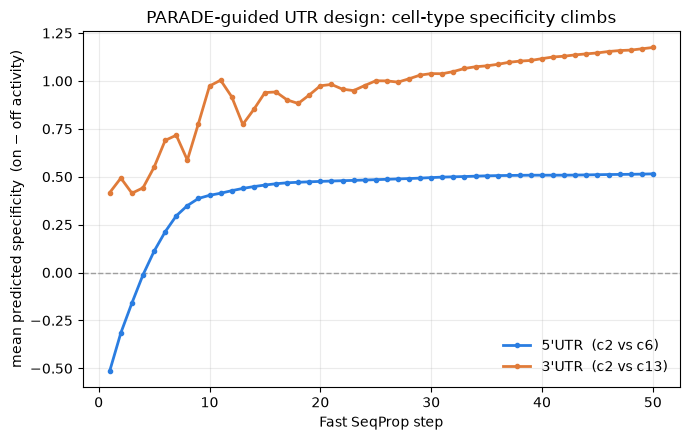

In [21]:
fig, ax = plt.subplots(figsize=(7, 4.5))
# One line per construct type; markers every step so the trajectory is easy to read.
ax.plot(range(1, len(hist_utr5) + 1), hist_utr5, color="#2a7de1", marker="o", ms=3, lw=2, label="5'UTR  (c2 vs c6)")
ax.plot(range(1, len(hist_utr3) + 1), hist_utr3, color="#e07b39", marker="o", ms=3, lw=2, label="3'UTR  (c2 vs c13)")
ax.axhline(0.0, color="0.6", lw=1, ls="--", zorder=0)  # zero specificity reference
ax.set_xlabel("Fast SeqProp step")
ax.set_ylabel("mean predicted specificity  (on \u2212 off activity)")
ax.set_title("PARADE-guided UTR design: cell-type specificity climbs")
ax.legend(frameon=False)
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

### Verify the designs in discrete space

The loop optimizes *relaxed* logits; what ultimately matters is the discrete `argmax` sequence. We re-score the decoded designs with `parade-activity` and compare their specificity to random sequences of the same length — the designs should be far more specific.

In [22]:
def discrete_specificity(construct_type, seqs, on, off):
    """Mean (on - off) activity for a list of concrete sequences, via parade-activity."""
    out = run_parade_activity(
        ParadeActivityInput(sequences=seqs),
        ParadeActivityConfig(construct_type=construct_type, cell_types=[on, off], device=DEVICE),
    )
    return float(np.mean([r.scores[on] - r.scores[off] for r in out.results]))


# Random-sequence baselines of the same length, for reference.
rng = np.random.default_rng(1)
random_utr5 = ["".join(rng.choice(list(VOCAB), 50)) for _ in range(8)]
random_utr3 = ["".join(rng.choice(list(VOCAB), 240)) for _ in range(8)]  # match the 240-nt designs

rows = [
    ("5'UTR c2-c6", discrete_specificity("utr5", designs_utr5, "c2", "c6"),
                    discrete_specificity("utr5", random_utr5, "c2", "c6")),
    ("3'UTR c2-c13", discrete_specificity("utr3", designs_utr3, "c2", "c13"),
                     discrete_specificity("utr3", random_utr3, "c2", "c13")),
]
header = ("panel", "designed", "random")
print(f"{header[0]:<16}{header[1]:>10}{header[2]:>10}")
for panel, designed, random_ in rows:
    print(f"{panel:<16}{designed:>10.3f}{random_:>10.3f}")

Running run_parade_activity [00:00]

Running run_parade_activity [00:00]

Running run_parade_activity [00:00]

Running run_parade_activity [00:00]

panel             designed    random
5'UTR c2-c6          0.503     0.098
3'UTR c2-c13         0.908     0.002


## Export Results

Every scorer output exports to its supported formats (`json`, `csv`).

In [23]:
from pathlib import Path

output_dir = Path("./example_output")
output_dir.mkdir(exist_ok=True)

activity.export(name="parade_activity", export_path=output_dir, file_format="csv")
stability.export(name="parade_stability", export_path=output_dir, file_format="json")
print(f"Results exported to {output_dir}/")

Results exported to example_output/
